In [ ]:
# import libraries
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from utils import load_data, evaluate_model, plot_roc, plot_confusion

In [116]:
# load dataset
df = load_data()

# model features
X = df.iloc[:, :-1] # take out target variable
print(list(X.columns))

# target variable
y = df["target"]

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


In [117]:
# logistic regression classifier
log = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        random_state=42
    ))
])

# MLP classifier
mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(8,4),
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.15,
        alpha=1e-4,
        random_state=42
    ))
])

# random forest classifier
rf = RandomForestClassifier(
    n_estimators=500,
    max_features="log2",
    max_depth=5,
    random_state=42,
)

In [118]:
# fit and evaluate each model
models = {
    "Logistic Regression": log,
    "MLP": mlp,
    "Random Forest": rf
}

for name, model in models.items():
    model.fit(X_train,y_train)
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    print(f"{name} Training Accuracy:", f"{train_acc:.2f}")
    print(f"{name} Testing Accuracy:", f"{test_acc:.2f}")

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = evaluate_model(model, X_test, y_test)

# Convert to DataFrame
results_df = pd.DataFrame(results).T

# Round for cleanliness
results_df = results_df.round(3)

results_df

Logistic Regression Training Accuracy: 0.99
Logistic Regression Testing Accuracy: 0.98
MLP Training Accuracy: 0.94
MLP Testing Accuracy: 0.89
Random Forest Training Accuracy: 0.99
Random Forest Testing Accuracy: 0.96


,accuracy,precision,roc_auc
Logistic Regression,0.982,0.986,0.995
MLP,0.895,0.969,0.985
Random Forest,0.956,0.959,0.992


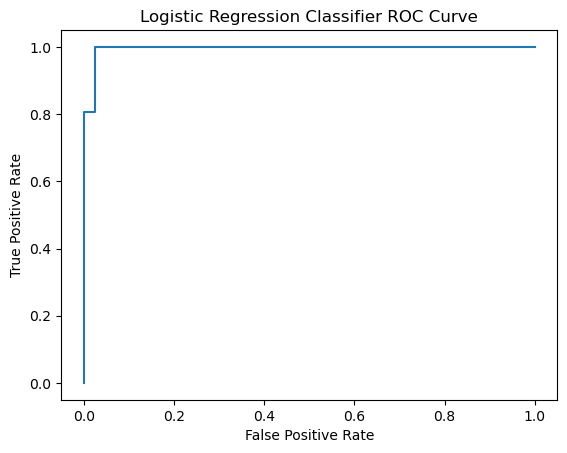

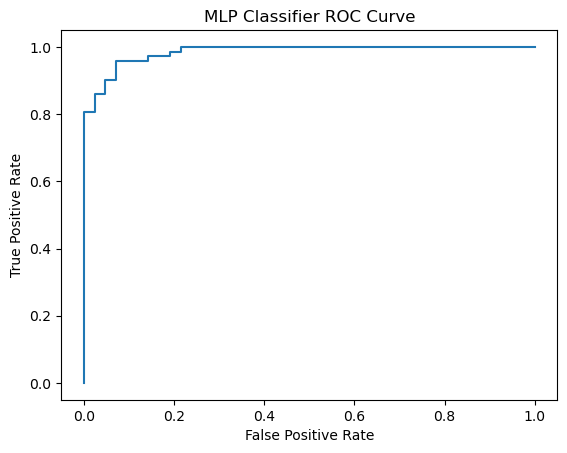

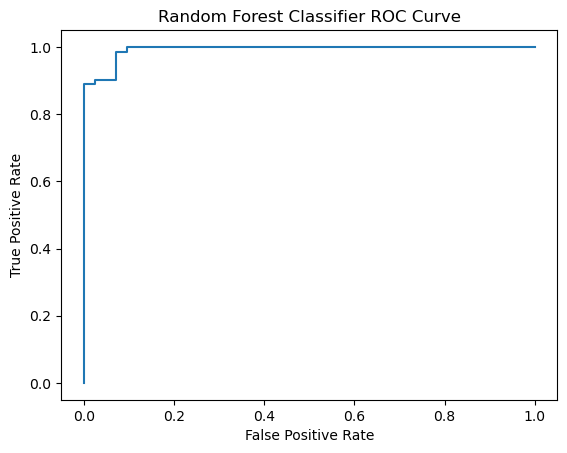

In [119]:
# roc curves
plot_roc(log, X_test, y_test, "Logistic Regression Classifier")
plot_roc(mlp, X_test, y_test, "MLP Classifier")
plot_roc(rf, X_test, y_test, "Random Forest Classifier")

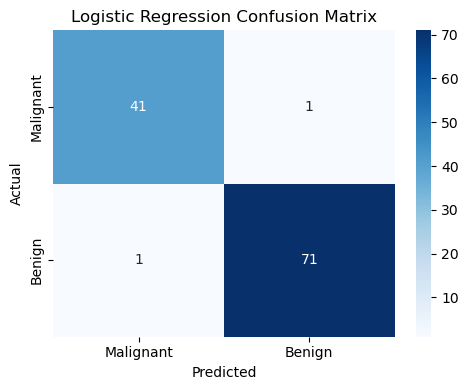

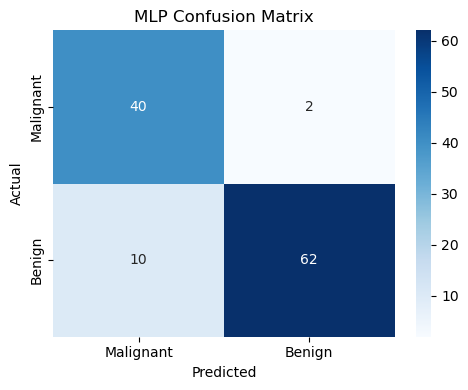

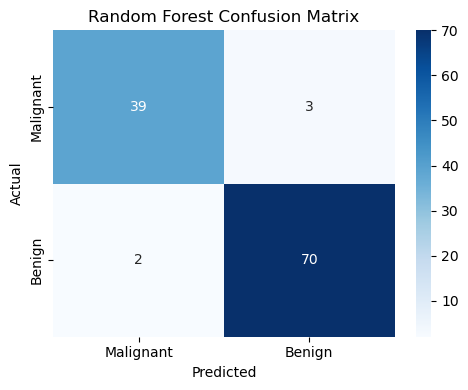

In [120]:
# confusion matrices
models = {
    "Logistic Regression": log,
    "MLP": mlp,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    plot_confusion(
        y_true=y_test,
        y_pred=y_pred,
        model_name=name,
        labels=["Malignant", "Benign"]
    )